In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e10/sample_submission.csv
/kaggle/input/playground-series-s5e10/train.csv
/kaggle/input/playground-series-s5e10/test.csv


In [2]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [3]:
training_data = pd.read_csv("/kaggle/input/playground-series-s5e10/train.csv", index_col=0)

In [4]:
training_data.shape

(517754, 13)

In [5]:
training_data.head()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
id,,,,,,,,,,,,,
0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


In [6]:
training_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 517754 entries, 0 to 517753
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   road_type               517754 non-null  object 
 1   num_lanes               517754 non-null  int64  
 2   curvature               517754 non-null  float64
 3   speed_limit             517754 non-null  int64  
 4   lighting                517754 non-null  object 
 5   weather                 517754 non-null  object 
 6   road_signs_present      517754 non-null  bool   
 7   public_road             517754 non-null  bool   
 8   time_of_day             517754 non-null  object 
 9   holiday                 517754 non-null  bool   
 10  school_season           517754 non-null  bool   
 11  num_reported_accidents  517754 non-null  int64  
 12  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(2), int64(3), object(4)
memory usage: 41.5+ MB


In [7]:
training_data.describe().T

,count,mean,std,min,25%,50%,75%,max
num_lanes,517754.0,2.491511,1.120434,1.0,1.00,2.00,3.00,4.0
curvature,517754.0,0.488719,0.272563,0.0,0.26,0.51,0.71,1.0
speed_limit,517754.0,46.112575,15.788521,25.0,35.00,45.00,60.00,70.0
num_reported_accidents,517754.0,1.187970,0.895961,0.0,1.00,1.00,2.00,7.0
accident_risk,517754.0,0.352377,0.166417,0.0,0.23,0.34,0.46,1.0


In [8]:
training_data.describe(include='object').T

,count,unique,top,freq
road_type,517754,3,highway,173672
lighting,517754,3,dim,183826
weather,517754,3,foggy,181463
time_of_day,517754,3,morning,173410


In [9]:
training_data.isnull().sum()

road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
accident_risk             0
dtype: int64

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


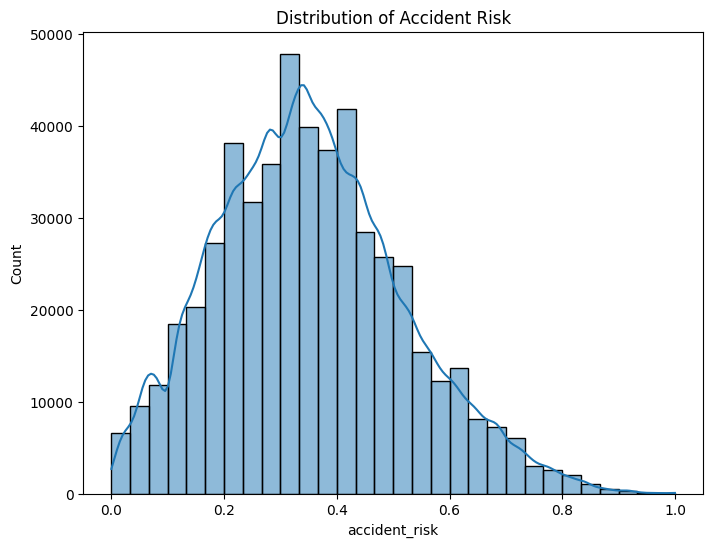

In [10]:
plt.figure(figsize=(8, 6))

sns.histplot(training_data['accident_risk'], kde=True, bins=30)
plt.title("Distribution of Accident Risk")
plt.show()

## Plotting the feature correlation 

In [11]:
y = training_data['accident_risk']
X = training_data.drop('accident_risk', axis=1)


numerical_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(include='object').columns

In [12]:
#Calculating the correlation between target variable and the numeric features
numeric_df = training_data[list(numerical_features) + ['accident_risk']].copy()
corr_matrix = numeric_df.corr()

In [13]:
# Create a temporary series for the 'encoded' features
encoded_features = pd.Series(index=categorical_features, dtype=float)

for col in categorical_features:
    # Calculate the mean of the target for each category
    # .map() replaces the original category value with the calculated mean
    temp_encoded_col = training_data.groupby(col)['accident_risk'].mean()
    
    # Calculate the correlation between the encoded column and the target
    # This acts as a proxy for the Eta-Squared (n^2) value
    encoded_corr = temp_encoded_col.corr(training_data.groupby(col)['accident_risk'].mean()) 
    
    # Store the correlation value
    encoded_features[col] = encoded_corr

    # OPTIONAL: Add the mean-encoded column to the numeric DataFrame for the full correlation plot
    # This allows you to see all feature-to-feature correlations
    numeric_df[f'{col}_mean_encoded'] = training_data[col].map(temp_encoded_col)

# Recalculate the full correlation matrix with mean-encoded categorical features
full_corr_matrix = numeric_df.corr()

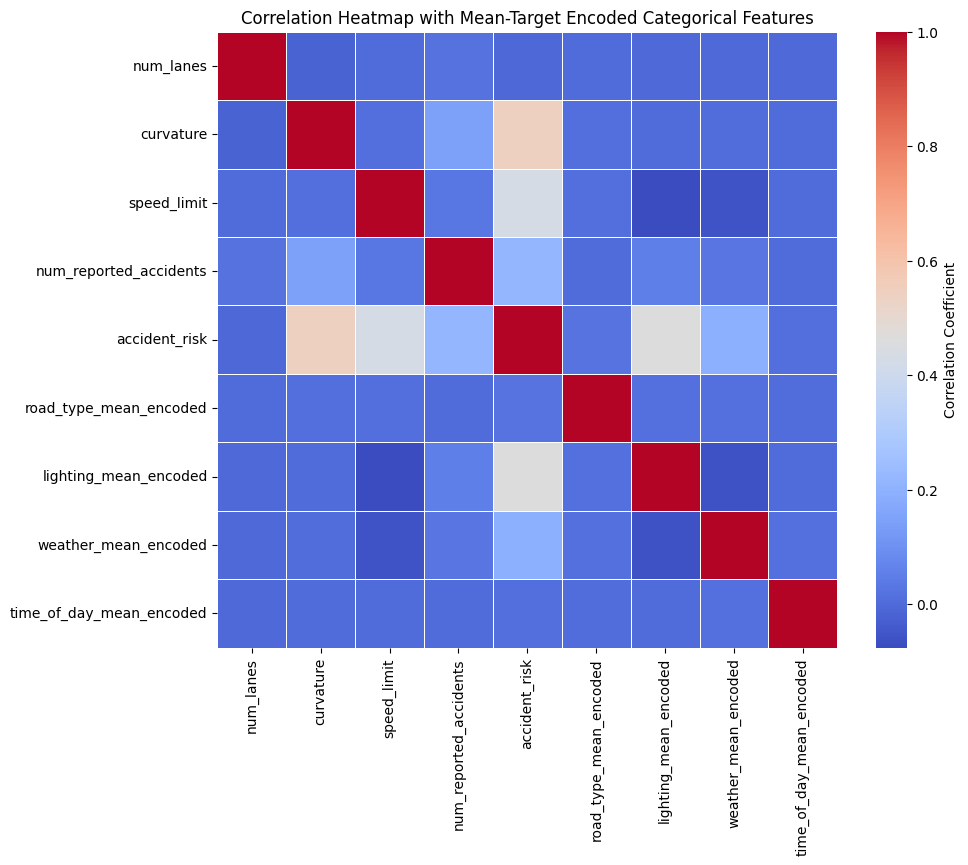

In [14]:
# Select only the target row/column for a more focused view (optional)
# We will plot the full matrix for a complete picture
plt.figure(figsize=(10, 8))
sns.heatmap(
    full_corr_matrix, 
    annot=False,  # Set to True for smaller datasets
    cmap='coolwarm',
    fmt=".2f",
    linewidths=.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Correlation Heatmap with Mean-Target Encoded Categorical Features')
plt.show()

In [15]:
numerical = ['num_lanes', 'curvature', 'speed_limit', 'num_reported_accidents'] 
categorical = ['road_type', 'lighting', 'weather', 'road_signs_present', 'public_road', 'time_of_day', 'holiday', 'school_season'] 
target = 'accident_risk'


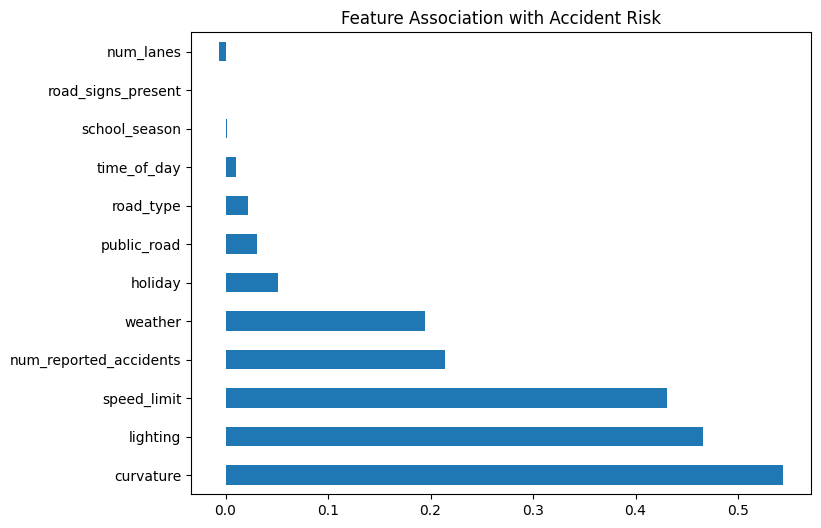

In [16]:
corr_summary = {}

#Numerical to Target Correlation - Pearson Coefficient 
for col in numerical:
    corr_summary[col] = training_data[col].corr(training_data[target])


#Categorical to Target Correlation - Mean-Target Encoding Proxy
for col in categorical:
    mean_target_per_category = training_data.groupby(col)[target].mean()
    # Map the mean back to the original column
    temp_encoded = training_data[col].map(mean_target_per_category)
    # The correlation of this encoded feature with the target is the strength of association
    corr_summary[col] = temp_encoded.corr(training_data[target])


# Plot the correlations with the target
pd.Series(corr_summary).sort_values(ascending=False).plot(kind='barh', figsize=(8, 6))
plt.title('Feature Association with Accident Risk')
plt.show()

## Gradient Boosted Tree Implementation

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

2025-10-04 00:33:01.998934: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759537982.196460      59 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759537982.256900      59 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [18]:
X = training_data.drop('accident_risk', axis=1)
y = training_data['accident_risk']


#Creating a preprocessor for tree models
tree_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical),
        ('num', 'passthrough', numerical)
    ],
    remainder='drop'
)

#Applying the preprocessing and splitting the data into train and valid set
X_processed_tree = tree_preprocessor.fit_transform(X)

X_train, X_valid, y_train, y_valid = train_test_split(X_processed_tree, y, test_size=0.2, random_state=42)

In [19]:
# Initialize and Train the LightGBM Regressor
lgbm = lgb.LGBMRegressor(
    objective='mse',
    n_estimators=1000,
    learning_rate=0.05,
    n_jobs=-1,
    random_state=42
)

lgbm.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric='rmse', # Use Root Mean Squared Error
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

# Evaluate
y_pred_lgbm = lgbm.predict(X_valid)
rmse_lgbm = mean_squared_error(y_valid, y_pred_lgbm, squared=False)
print(f"(LightGBM) RMSE: {rmse_lgbm}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010099 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 167
[LightGBM] [Info] Number of data points in the train set: 414203, number of used features: 12
[LightGBM] [Info] Start training from score 0.352605
(LightGBM) RMSE: 0.056231591260006854


## Multilayer Perceptron Implementation

In [20]:
# Create a preprocessor pipeline for the Neural Network
nn_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical), # Scale numerical features
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical) # One-hot encode categorical features
    ],
    remainder='drop'
)

# Apply preprocessing and split
X_processed_nn = nn_preprocessor.fit_transform(X)
X_train_nn, X_valid_nn, y_train_nn, y_valid_nn = train_test_split(X_processed_nn, y, test_size=0.2, random_state=42)

In [21]:
# Get the number of input features after OHE
input_dim = X_train_nn.shape[1]

# 1. Define the Model Architecture
model = Sequential([
    Dense(64, activation='relu', input_shape=(input_dim,)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    # Output Layer: Single neuron with a 'linear' activation for regression
    Dense(1, activation='linear') 
])

# 2. Compile the Model
model.compile(
    optimizer='adam', 
    loss='mean_squared_error', 
    metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse')]
)

# 3. Train the Model
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = model.fit(
    X_train_nn, y_train_nn,
    epochs=100,
    batch_size=128,  
    validation_data=(X_valid_nn, y_valid_nn),
    callbacks=[early_stopping],
    verbose=0
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-10-04 00:33:32.370496: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


(MLP) RMSE: 0.05678001418709755


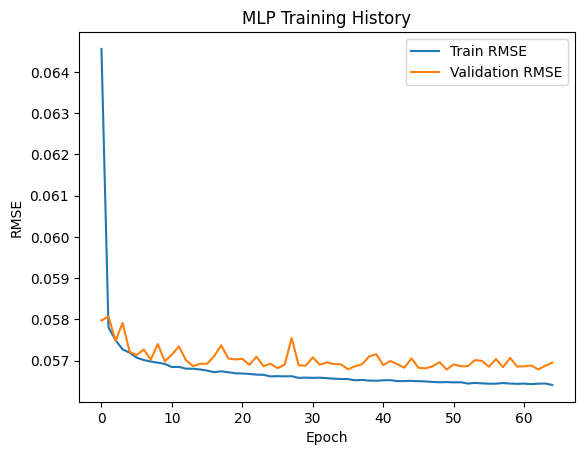

In [22]:
# Evaluate on the test set
loss, rmse_nn = model.evaluate(X_valid_nn, y_valid_nn, verbose=0)
print(f"(MLP) RMSE: {rmse_nn}")

# Plotting the training history
plt.plot(history.history['rmse'], label='Train RMSE')
plt.plot(history.history['val_rmse'], label='Validation RMSE')
plt.title('MLP Training History')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.legend()
plt.show()

In [23]:
testing_data = pd.read_csv("/kaggle/input/playground-series-s5e10/test.csv", index_col=0)

In [24]:
testing_data.head()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents
id,,,,,,,,,,,,
517754,highway,2,0.34,45,night,clear,True,True,afternoon,True,True,1
517755,urban,3,0.04,45,dim,foggy,True,False,afternoon,True,False,0
517756,urban,2,0.59,35,dim,clear,True,False,afternoon,True,True,1
517757,rural,4,0.95,35,daylight,rainy,False,False,afternoon,False,False,2
517758,highway,2,0.86,35,daylight,clear,True,False,evening,False,True,3


In [25]:
tree_preprocessor = ColumnTransformer(transformers=[('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical),('num', 'passthrough', numerical)],remainder='drop')

X_processed_test = tree_preprocessor.fit_transform(testing_data)

nn_preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), numerical), # Scale numerical features
                    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical) # One-hot encode categorical features
    ],remainder='drop')

X_test_nn = nn_preprocessor.fit_transform(testing_data)

In [26]:
y_test = lgbm.predict(X_processed_test)

In [28]:
y_test

array([0.28948431, 0.12436606, 0.18419924, ..., 0.25012178, 0.12983293,
       0.48791996])